h = 0.01 -> unstable
h = 0.1 -> unstable
h = 0.5 -> unstable
h = 1.0 -> unstable


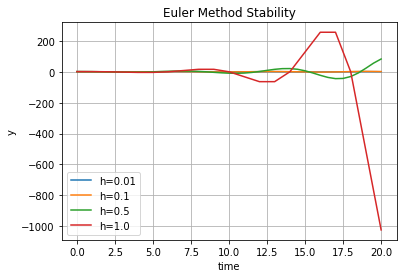

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# constants
k = 1
h_list = [0.01, 0.1, 0.5, 1.0]

t0 = 0
t_end = 20

y0 = 1
v0 = 0


def euler(h):
    t = np.arange(t0, t_end + h, h)
    y = np.zeros(len(t))
    v = np.zeros(len(t))

    # starting values
    y[0] = y0
    v[0] = v0

    # euler loop
    for i in range(1, len(t)):
        y[i] = y[i-1] + h * v[i-1]
        v[i] = v[i-1] + h * (-k * y[i-1])

    # stability check
    A = np.array([[1, h], [-h*k, 1]])
    eig = np.linalg.eigvals(A)

    if max(abs(eig)) >= 1:
        print("h =", h, "-> unstable")
    else:
        print("h =", h, "-> stable")

    return t, y


# plotting
plt.figure()

for h in h_list:
    t, y = euler(h)
    plt.plot(t, y, label="h=" + str(h))

plt.xlabel("time")
plt.ylabel("y")
plt.title("Euler Method Stability")
plt.legend()
plt.grid()

plt.show()